<a href="https://colab.research.google.com/github/GarciaQuinteroAngelAlonso/Procesos-Estocasticos/blob/main/GarciaQuintero_Descomposici%C3%B3nCan%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

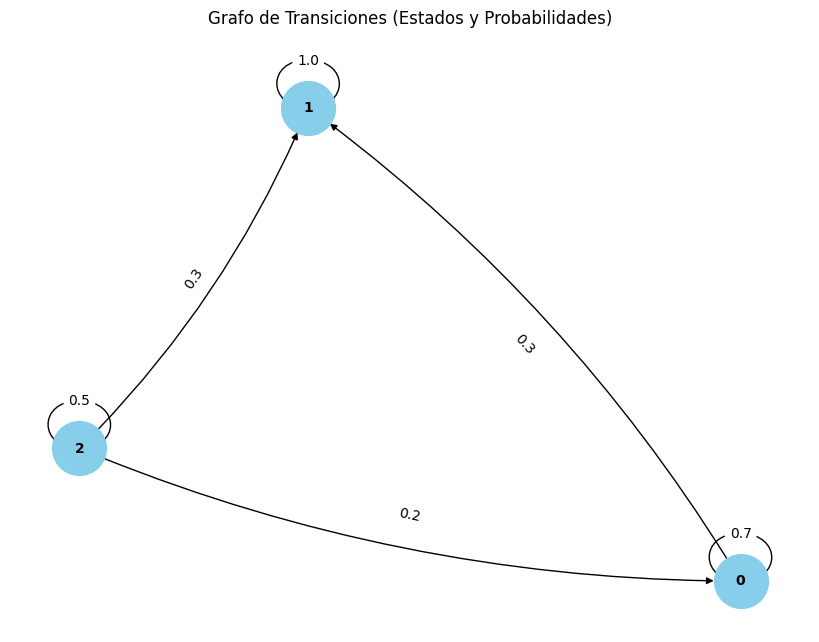

RESULTADOS DEL ANÁLISIS
Clases detectadas:   [[0], [1], [2]]
Estados Recurrentes: [1]
Estados Transitorios: [0, 2]
Nuevo Orden:         [1, 0, 2]

MATRIZ CANÓNICA (P*):
[[1.  0.  0. ]
 [0.3 0.7 0. ]
 [0.3 0.2 0.5]]

Distribución Estacionaria (pi):
[0. 1. 0.]


In [17]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def validar_matriz(P):
    """Verifica que la matriz de entrada sea una matriz estocástica válida."""
    if P.shape[0] != P.shape[1]:
        raise ValueError("Error: La matriz debe ser cuadrada (n x n).")
    if np.any(P < 0):
        raise ValueError("Error: La matriz contiene probabilidades negativas.")
    # Usamos all close para tolerar pequeñas imprecisiones de punto flotante
    if not np.allclose(P.sum(axis=1), 1):
        raise ValueError("Error: Cada fila de la matriz de transición debe sumar 1.")
    return True
def dibujar_diagrama(P):
    """Genera una visualización gráfica de la cadena de Markov usando Networkx"""
    n = P.shape[0]
    G = nx.DiGraph() # Grafo dirigido
    # Añadir nodos y aristas basadas en probabilidades mayores a cero
    for i in range(n):
        G.add_node(i)
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j, weight=P[i, j])
    # Configuración del diseño visual
    pos = nx.spring_layout(G, seed=10)
    plt.figure(figsize=(8, 6))
    nx.draw(
        G, pos, with_labels=True, node_size=1500,
        node_color="skyblue", font_size=10,
        font_weight="bold", arrows=True,
        connectionstyle='arc3, rad = 0.1' # Curvatura para evitar solapamiento
    )
    # Dibujar etiquetas de las probabilidades en las flechas
    etiquetas = nx.get_edge_attributes(G, "weight")
    etiquetas = {k: round(v, 2) for k, v in etiquetas.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas)
    plt.title("Grafo de Transiciones (Estados y Probabilidades)")
    plt.show()
def obtener_clases(P):
    """
    Identifica las clases de comunicación mediante la clausura transitiva."""
    n = P.shape[0]
    adj = (P > 0).astype(int)
    # Matriz de alcanzabilidad: (I + A)^(n-1) determina si hay camino de i a j
    alcanzable = np.linalg.matrix_power(np.eye(n, dtype=int) + adj, n - 1) > 0
    # Dos estados se comunican si i alcanza a j Y j alcanza a i
    comunicacion = alcanzable & alcanzable.T
    visitado = np.zeros(n, dtype=bool)
    clases = []
    for i in range(n):
        if not visitado[i]:
            # Extraer todos los estados que se comunican con i
            clase = list(map(int, np.where(comunicacion[i])[0]))
            clases.append(clase)
            visitado[clase] = True
    return clases, alcanzable
def forma_canonica(P):
    """Reorganiza la matriz P en su forma canónica dividiéndola en submatrices.
    Estructura resultante:
    [[R, 0],
     [A, B]]
    Donde R son estados recurrentes y B son transitorios."""
    validar_matriz(P)
    clases, alcanzable = obtener_clases(P)
    recurrentes = []
    transitorios = []
    # Clasificar cada clase como recurrente o transitoria
    for clase in clases:
        clase_set = set(clase)
        es_recurrente = True
        for estado in clase:
            # Si un estado puede alcanzar algo fuera de su propia clase, es transitoria
            destinos = set(map(int, np.where(alcanzable[estado])[0]))
            if not destinos.issubset(clase_set):
                es_recurrente = False
                break
        if es_recurrente:
            recurrentes.extend(clase)
        else:
            transitorios.extend(clase)
    # Reordenar índices: Recurrentes primero (arriba-izquierda), Transitorios después
    nuevo_orden = recurrentes + transitorios
    P_canonica = P[np.ix_(nuevo_orden, nuevo_orden)]
    # Partición de submatrices
    r = len(recurrentes)
    subR = P_canonica[:r, :r]      # Transiciones entre recurrentes
    subCero = P_canonica[:r, r:]   # Debe ser siempre cero
    subA = P_canonica[r:, :r]      # De transitorios a recurrentes (absorción)
    subB = P_canonica[r:, r:]      # Transiciones entre transitorios
    return P_canonica, nuevo_orden, recurrentes, transitorios, clases, subR, subCero, subA, subB
def distribucion_estacionaria(M):
    """Calcula el vector de probabilidad invariante (pi) tal que pi * M = pi.
    Resuelve el sistema mediante mínimos cuadrados para mayor estabilidad."""
    n = M.shape[0]
    # Planteamiento: pi(M - I) = 0  => (M.T - I) * pi^T = 0
    A = M.T - np.eye(n)
    # Condición de normalización: la suma de probabilidades debe ser 1
    A = np.vstack([A, np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    # Resolvemos el sistema sobredeterminado
    pi, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    pi = np.maximum(pi, 0) # Corregir errores de precisión (evitar negativos)
    return pi / pi.sum()

# BLOQUE DE PRUEBA
if __name__ == "__main__":
    # Definimos una matriz de ejemplo con 1 estado absorbente (1),
    # una clase recurrente (0) y un estado transitorio (2).
    P_test = np.array([
        [0.7, 0.3, 0.0],
        [0.0, 1.0, 0.0],
        [0.2, 0.3, 0.5]
    ])

    try:
        # 1. Visualización
        dibujar_diagrama(P_test)

        # 2. Análisis Estructural
        res = forma_canonica(P_test)
        p_can, orden, rec, trans, clases, R, Cero, A, B = res

        print("RESULTADOS DEL ANÁLISIS")
        print(f"Clases detectadas:   {clases}")
        print(f"Estados Recurrentes: {rec}")
        print(f"Estados Transitorios: {trans}")
        print(f"Nuevo Orden:         {orden}")

        print("\nMATRIZ CANÓNICA (P*):")
        print(np.round(p_can, 4))

        # 3. Cálculo de la distribución a largo plazo
        pi = distribucion_estacionaria(P_test)
        print(f"\nDistribución Estacionaria (pi):\n{np.round(pi, 4)}")

    except ValueError as e:
        print(e)